# Лабораторная работа №1
## «Предобработка и очистка данных»

**Датасет:** `kidney_disease.xlsx`

**Цель работы:** выполнить предварительную обработку данных: изучить структуру набора, найти и обработать дубликаты, пропуски и выбросы, исправить типы данных, а затем проверить результат очистки на искусственно испорченном наборе.


## 0. Подготовка окружения

Для работы используем `pandas` и `numpy`. Для графиков используем `matplotlib` и `seaborn`, а для метода ближайших соседей — `KNNImputer` из `scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set_theme(style='whitegrid')

## 1. Загрузка и первичное изучение данных


In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
    file_name = next(iter(uploaded))
except ImportError:
    file_name = 'kidney_disease.xlsx'

df = pd.read_excel(file_name)

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('Первые 5 строк:')
print(df.head().to_string(index=False))

Saving kidney_disease.xlsx to kidney_disease (1).xlsx
Размер датасета: 400 строк, 15 столбцов
Первые 5 строк:
 Возраст (age)  Давление (bp)  Удельный_вес_мочи (sg)  Альбумин (al)  Глюкоза_крови (bgr)  Креатинин (sc)  Гемоглобин (hemo) Гематокрит (pcv) Лейкоциты_крови (wc) Эритроциты_крови (rc) Эритроциты_мочи (rbc) Гнойные_клетки (pc) Гипертония (htn) Сахарный_диабет (dm) Диагноз (classification)
            48         80.000                   1.020          1.000              121.000           1.200             15.400               44                 7800                   5.2                   NaN              normal              yes                  yes                      ckd
             7         50.000                   1.020          4.000                  NaN           0.800             11.300               38                 6000                   NaN                   NaN              normal               no                   no                      ckd
            62      

### 1.1. Проверка структуры методом `.info()`

Метод `.info()` показывает количество записей, наличие пропусков и тип хранения каждого признака. На этом этапе особенно важно найти признаки, у которых тип хранения не соответствует их смыслу.

В исходном файле ожидается проблема с `pcv`, `wc` и `rc`: это числовые медицинские показатели, но часть их значений записана как текст.



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Возраст (age)             400 non-null    int64  
 1   Давление (bp)             388 non-null    float64
 2   Удельный_вес_мочи (sg)    353 non-null    float64
 3   Альбумин (al)             354 non-null    float64
 4   Глюкоза_крови (bgr)       356 non-null    float64
 5   Креатинин (sc)            383 non-null    float64
 6   Гемоглобин (hemo)         348 non-null    float64
 7   Гематокрит (pcv)          330 non-null    object 
 8   Лейкоциты_крови (wc)      295 non-null    object 
 9   Эритроциты_крови (rc)     270 non-null    object 
 10  Эритроциты_мочи (rbc)     248 non-null    object 
 11  Гнойные_клетки (pc)       335 non-null    object 
 12  Гипертония (htn)          398 non-null    object 
 13  Сахарный_диабет (dm)      398 non-null    object 
 14  Диагноз (c

### 1.2. Описательная статистика

Посмотрим основные статистические характеристики числовых признаков. Табличный вывод здесь полезен, потому что содержит сразу много признаков и позволяет сравнивать их диапазоны.

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Возраст (age),400.000,51.140,17.452,2.000,41.000,54.000,64.250,90.000
Давление (bp),388.000,76.469,13.684,50.000,70.000,80.000,80.000,180.000
Удельный_вес_мочи (sg),353.000,1.017,0.006,1.005,1.010,1.020,1.020,1.025
Альбумин (al),354.000,1.017,1.353,0.000,0.000,0.000,2.000,5.000
Глюкоза_крови (bgr),356.000,148.037,79.282,22.000,99.000,121.000,163.000,490.000
Креатинин (sc),383.000,3.072,5.741,0.400,0.900,1.300,2.800,76.000
Гемоглобин (hemo),348.000,12.526,2.913,3.100,10.300,12.650,15.000,17.800


### 1.3. Анализ пропущенных значений

Определим количество и долю пропусков в каждом столбце. Большая таблица здесь оправдана, потому что нам нужно оценить все признаки и сравнить степень заполненности.

In [5]:
missing = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Доля пропусков, %': (df.isna().mean() * 100).round(2)
})
missing = missing.sort_values('Количество пропусков', ascending=False)
display(missing)

,Количество пропусков,"Доля пропусков, %"
Эритроциты_мочи (rbc),152,38.000
Эритроциты_крови (rc),130,32.500
Лейкоциты_крови (wc),105,26.250
Гематокрит (pcv),70,17.500
Гнойные_клетки (pc),65,16.250
Гемоглобин (hemo),52,13.000
Удельный_вес_мочи (sg),47,11.750
Альбумин (al),46,11.500
Глюкоза_крови (bgr),44,11.000
Креатинин (sc),17,4.250


**Визуализация пропусков.**

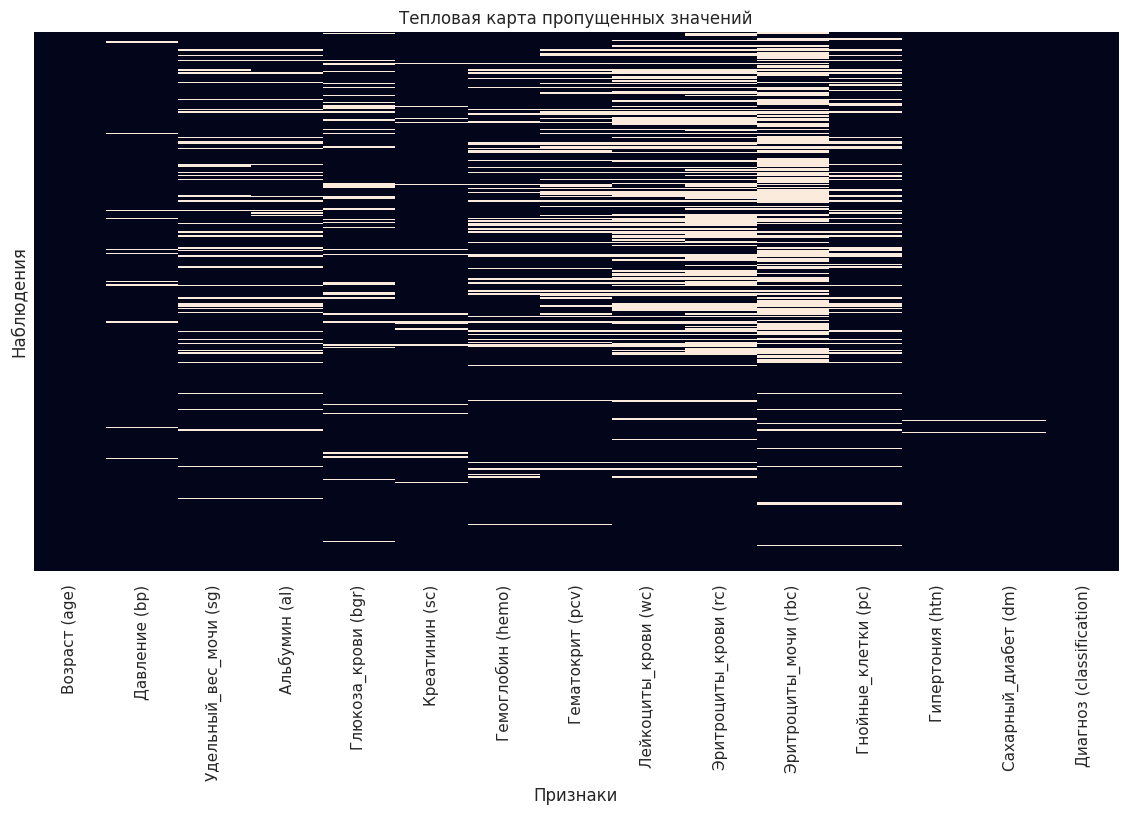

In [6]:
plt.figure(figsize=(14, 7))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Тепловая карта пропущенных значений')
plt.xlabel('Признаки')
plt.ylabel('Наблюдения')
plt.show()

### 1.4. Проверка соответствия типов смыслу признаков

Сначала посмотрим, какие столбцы pandas считает текстовыми. Затем приведём числовые по смыслу признаки к числовому типу. При этом пропуски пока не заполняем.

In [7]:
print('Текстовые столбцы в исходных данных:')
print(df.select_dtypes(include='object').columns.tolist())

numeric_cols = [
    'Возраст (age)',
    'Давление (bp)',
    'Удельный_вес_мочи (sg)',
    'Альбумин (al)',
    'Глюкоза_крови (bgr)',
    'Креатинин (sc)',
    'Гемоглобин (hemo)',
    'Гематокрит (pcv)',
    'Лейкоциты_крови (wc)',
    'Эритроциты_крови (rc)'
]

integer_cols = [
    'Возраст (age)',
    'Давление (bp)',
    'Альбумин (al)',
    'Глюкоза_крови (bgr)',
    'Гематокрит (pcv)',
    'Лейкоциты_крови (wc)'
]

categorical_cols = [
    'Эритроциты_мочи (rbc)',
    'Гнойные_клетки (pc)',
    'Гипертония (htn)',
    'Сахарный_диабет (dm)',
    'Диагноз (classification)'
]

# Убираем лишние пробелы и табуляцию в текстовых значениях.
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)

# Маркер '?' считаем пропуском.
df = df.replace('?', np.nan)

# Признаки, которые по смыслу являются числовыми, переводим в numeric.
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Типы данных после исправления хранения:')
print(df.dtypes)

Текстовые столбцы в исходных данных:
['Гематокрит (pcv)', 'Лейкоциты_крови (wc)', 'Эритроциты_крови (rc)', 'Эритроциты_мочи (rbc)', 'Гнойные_клетки (pc)', 'Гипертония (htn)', 'Сахарный_диабет (dm)', 'Диагноз (classification)']
Типы данных после исправления хранения:
Возраст (age)                 int64
Давление (bp)               float64
Удельный_вес_мочи (sg)      float64
Альбумин (al)               float64
Глюкоза_крови (bgr)         float64
Креатинин (sc)              float64
Гемоглобин (hemo)           float64
Гематокрит (pcv)            float64
Лейкоциты_крови (wc)        float64
Эритроциты_крови (rc)       float64
Эритроциты_мочи (rbc)        object
Гнойные_клетки (pc)          object
Гипертония (htn)             object
Сахарный_диабет (dm)         object
Диагноз (classification)     object
dtype: object


После преобразования `pcv`, `wc` и `rc` стали числовыми. При этом столбцы с пропусками всё ещё могут иметь `float64` — это ожидаемо.

# 2. Обнаружение и обработка дубликатов

Дубликаты могут искусственно увеличивать число наблюдений. Сначала проверим полные совпадения строк, затем — скрытые дубликаты, вызванные пробелами, табуляцией и разными вариантами записи категорий.

In [8]:
full_duplicates = int(df.duplicated().sum())
print(f'Количество полных дубликатов: {full_duplicates}')

if full_duplicates > 0:
    print('Пример дублирующейся строки:')
    print(df[df.duplicated(keep=False)].head(1).to_string(index=False))
else:
    print('Полных дубликатов в исходном наборе не обнаружено.')

Количество полных дубликатов: 0
Полных дубликатов в исходном наборе не обнаружено.


### 2.1. Поиск скрытых дубликатов

Проверим категориальные признаки на наличие значений с лишними пробелами, табуляцией или отличиями только в регистре. Такие значения не являются разными категориями по смыслу и должны быть приведены к одному виду.

In [9]:
for col in categorical_cols:
    variants = []
    for value in df[col].dropna().astype(str).unique():
        if value != value.strip() or value != value.lower():
            variants.append(value)
    if variants:
        print(f'{col}: {variants[:10]}')

print('Проверка завершена: лишние пробелы и регистр в текстовых значениях нормализованы.')

Проверка завершена: лишние пробелы и регистр в текстовых значениях нормализованы.


### 2.2. Частичные дубликаты

Отдельного идентификатора пациента в наборе нет, поэтому совпадение нескольких признаков не означает автоматически, что это одна и та же запись. Для анализа возьмём комбинацию возраста, давления, гемоглобина, гематокрита и диагноза. Найденные совпадения будем считать кандидатами на проверку, а не удалять автоматически.

In [10]:
partial_key = [
    'Возраст (age)', 'Давление (bp)', 'Гемоглобин (hemo)',
    'Гематокрит (pcv)', 'Диагноз (classification)'
]

partial_counts = (
    df.dropna(subset=partial_key)
      .groupby(partial_key)
      .size()
      .reset_index(name='Количество записей')
)
partial_candidates = partial_counts[partial_counts['Количество записей'] > 1]

print(f'Групп частичных дубликатов: {len(partial_candidates)}')
if len(partial_candidates) > 0:
    print('Пример группы:')
    print(partial_candidates.head(1).to_string(index=False))

Групп частичных дубликатов: 1
Пример группы:
 Возраст (age)  Давление (bp)  Гемоглобин (hemo)  Гематокрит (pcv) Диагноз (classification)  Количество записей
            60         90.000             11.500            35.000                      ckd                   2


### 2.3. Итоговое решение по дубликатам

Для отчёта зафиксируем, какие проблемы обнаружены и как с ними поступаем. Полные дубликаты удаляем, скрытые категориальные варианты нормализуем, а частичные совпадения сохраняем до тех пор, пока нет доказательств, что это ошибочные повторения.

In [11]:
print('Проблема                         Решение')
print('-' * 72)
print(f'Полные дубликаты                 удалить: {full_duplicates}')
print('Скрытые категориальные значения  нормализовать: пробелы/регистр')
print(f'Частичные дубликаты              сохранить для проверки: {len(partial_candidates)} групп')

before_rows = len(df)
df = df.drop_duplicates().copy()
print(f'Строк после удаления полных дубликатов: {len(df)} (было {before_rows})')

Проблема                         Решение
------------------------------------------------------------------------
Полные дубликаты                 удалить: 0
Скрытые категориальные значения  нормализовать: пробелы/регистр
Частичные дубликаты              сохранить для проверки: 1 групп
Строк после удаления полных дубликатов: 400 (было 400)


# 3. Заполнение пропусков

Сравним несколько подходов. Удаление строк покажем как базовый вариант. Для числовых признаков рассмотрим заполнение медианой и метод ближайших соседей (KNN), а для категориальных — наиболее частым значением.

### 3.1. Вариант 1 — удаление строк с пропусками

Этот способ прост, но при большом количестве пропусков может привести к значительной потере данных. Поэтому сначала посчитаем, сколько строк останется.

In [12]:
df_dropna = df.dropna()
print(f'Было строк: {len(df)}')
print(f'Останется после удаления: {len(df_dropna)}')
print(f'Будет удалено: {len(df) - len(df_dropna)} строк')

Было строк: 400
Останется после удаления: 171
Будет удалено: 229 строк


### 3.2. Вариант 2 — медиана для числовых и мода для категориальных признаков

Медиана менее чувствительна к выбросам, чем среднее, поэтому для медицинских показателей она является удобным базовым способом заполнения пропусков. Для категориальных признаков используем наиболее часто встречающееся значение.

In [14]:
df_median = df.copy()

for col in numeric_cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

for col in categorical_cols:
    if df_median[col].isna().any():
        df_median[col] = df_median[col].fillna(df_median[col].mode()[0])

# После заполнения целочисленные по смыслу признаки переводим в int64.
for col in integer_cols:
    df_median[col] = df_median[col].round().astype('int64')

print('Пропусков после медианы/моды:', int(df_median.isna().sum().sum()))
print('Тип возраста:', df_median['Возраст (age)'].dtype)

Пропусков после медианы/моды: 0
Тип возраста: int64


### 3.3. Вариант 3 — ближайшие соседи (KNN)

KNN оценивает пропущенное значение по похожим наблюдениям. Метод полезен, когда между признаками есть взаимосвязи. Здесь применим его к числовым признакам, а категориальные пропуски заполним модой.

In [15]:
df_knn = df.copy()

X = df_knn[numeric_cols].copy()
med = X.median()
std = X.std().replace(0, 1)
X_scaled = (X - med) / std

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_scaled),
    columns=numeric_cols,
    index=df_knn.index
)

X_imputed = X_imputed * std + med
df_knn[numeric_cols] = X_imputed

for col in categorical_cols:
    if df_knn[col].isna().any():
        df_knn[col] = df_knn[col].fillna(df_knn[col].mode()[0])

for col in integer_cols:
    df_knn[col] = df_knn[col].round().astype('int64')

print('Пропусков после KNN:', int(df_knn.isna().sum().sum()))
print('Тип возраста после KNN:', df_knn['Возраст (age)'].dtype)

Пропусков после KNN: 0
Тип возраста после KNN: int64


### 3.4. Интерполяция

Интерполяция особенно полезна для временных рядов, когда известны значения до и после пропуска. В нашем датасете нет временного признака и наблюдения не образуют временной ряд, поэтому применять интерполяцию к медицинским наблюдениям здесь некорректно.

In [ ]:
print('Интерполяция не применяется: в датасете отсутствует временной признак.')

Интерполяция не применяется: в датасете отсутствует временной признак.


### 3.5. Выбор метода

Для основной версии очищенного набора выберем медиану для числовых признаков и моду для категориальных. Это простой и интерпретируемый вариант, который не создаёт искусственной зависимости от соседних строк.

In [16]:
df_clean = df_median.copy()
print('Выбран итоговый метод: медиана для числовых признаков + мода для категориальных.')

Выбран итоговый метод: медиана для числовых признаков + мода для категориальных.


# 4. Выявление выбросов

Сначала отделим явно некорректные значения от обычных статистических выбросов. Например, отрицательный возраст невозможен, а очень высокий, но физически возможный показатель не обязательно является ошибкой.

### 4.1. Проверка допустимых диапазонов

Проверим логически невозможные значения: возраст 0–120 лет, давление и лабораторные показатели не должны быть отрицательными. Для гематокрита ограничим диапазон 0–100, а для удельного веса мочи используем разумный учебный диапазон 1.000–1.030.

In [17]:
range_rules = {
    'Возраст (age)': (0, 120),
    'Давление (bp)': (0, np.inf),
    'Удельный_вес_мочи (sg)': (1.000, 1.030),
    'Альбумин (al)': (0, 5),
    'Глюкоза_крови (bgr)': (0, np.inf),
    'Креатинин (sc)': (0, np.inf),
    'Гемоглобин (hemo)': (0, np.inf),
    'Гематокрит (pcv)': (0, 100),
    'Лейкоциты_крови (wc)': (0, np.inf),
    'Эритроциты_крови (rc)': (0, np.inf)
}

for col, (low, high) in range_rules.items():
    bad = df[col].notna() & ((df[col] < low) | (df[col] > high))
    if bad.sum() > 0:
        print(f'{col}: {int(bad.sum())} значений вне допустимого диапазона')

print('Проверка диапазонов завершена.')

Проверка диапазонов завершена.


**Визуализация выбросов методом boxplot.** Ящиковые диаграммы позволяют увидеть медиану, квартили и наблюдения, находящиеся далеко от основной части распределения.

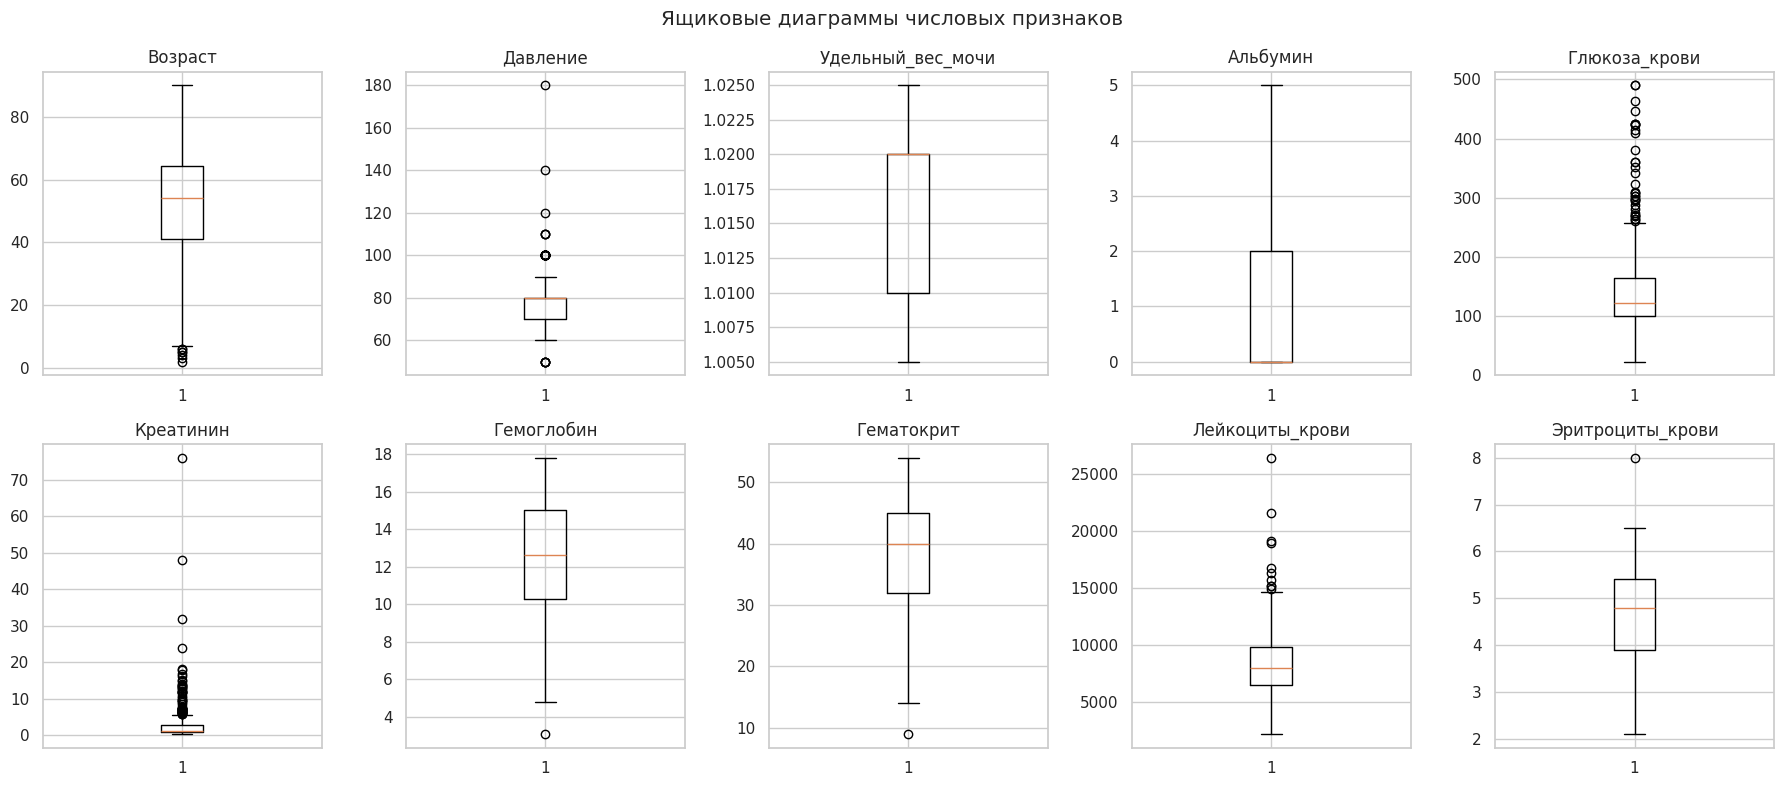

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col.split('(')[0].strip())
    ax.set_ylabel('')
plt.suptitle('Ящиковые диаграммы числовых признаков')
plt.tight_layout()
plt.show()

**Визуализация распределения.** Гистограммы показывают форму распределения и помогают понять, действительно ли отдельные значения резко отличаются от основной массы наблюдений.

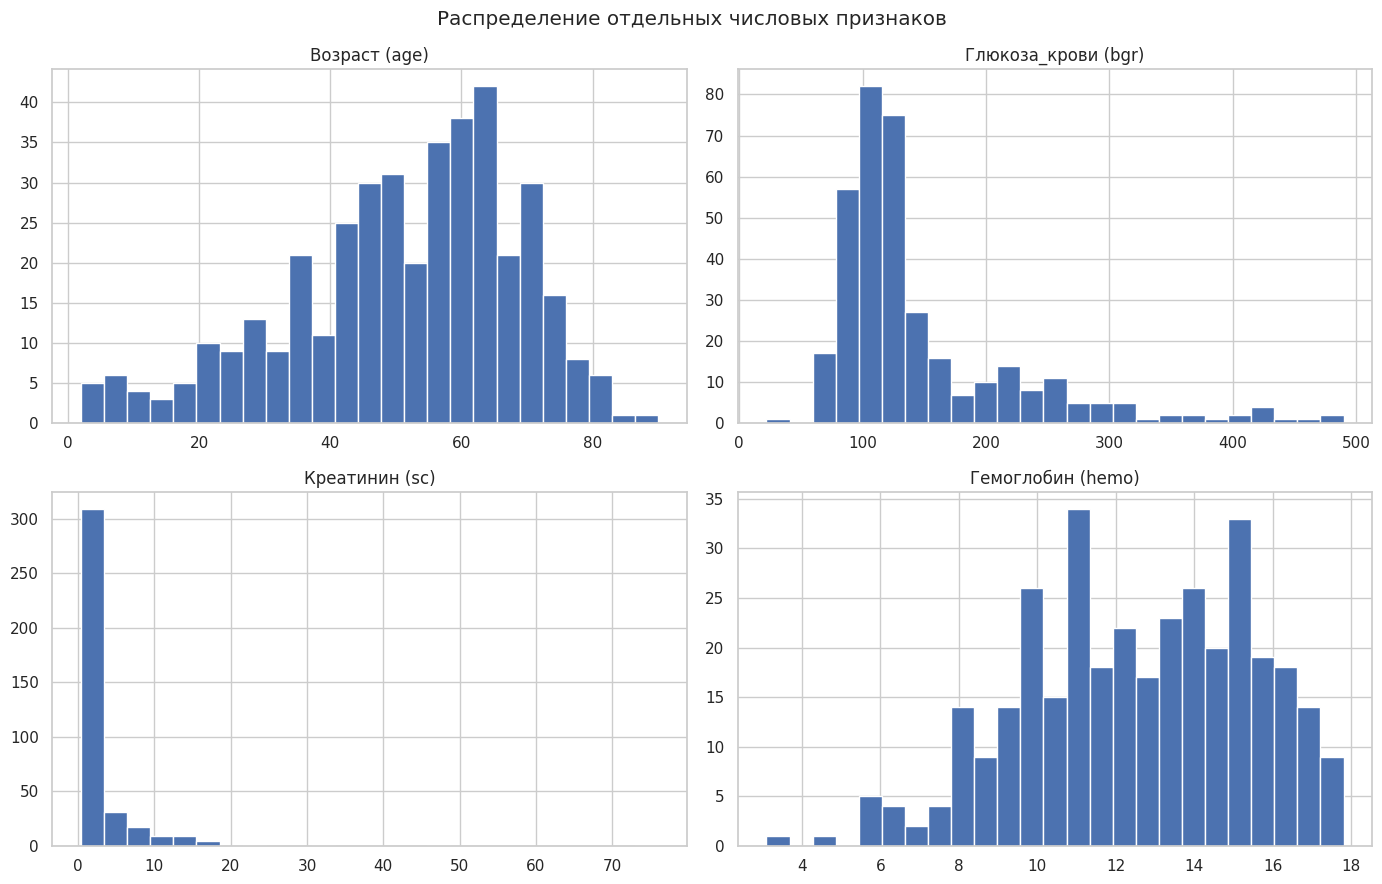

In [19]:
selected = ['Возраст (age)', 'Глюкоза_крови (bgr)', 'Креатинин (sc)', 'Гемоглобин (hemo)']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), selected):
    ax.hist(df[col].dropna(), bins=25)
    ax.set_title(col)
plt.suptitle('Распределение отдельных числовых признаков')
plt.tight_layout()
plt.show()

### 4.2. Метод межквартильного расстояния (IQR)

Для каждого числового признака вычислим первый и третий квартили. Значения ниже `Q1 - 1.5×IQR` или выше `Q3 + 1.5×IQR` считаются статистическими выбросами.

In [20]:
def iqr_outliers(data, col):
    s = data[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = data[col].notna() & ((data[col] < low) | (data[col] > high))
    return mask, low, high

rows = []
for col in numeric_cols:
    mask, low, high = iqr_outliers(df, col)
    rows.append([col, int(mask.sum()), round(low, 3), round(high, 3)])

iqr_table = pd.DataFrame(rows, columns=['Признак', 'Выбросов IQR', 'Нижняя граница', 'Верхняя граница'])
display(iqr_table)

,Признак,Выбросов IQR,Нижняя граница,Верхняя граница
0,Возраст (age),7,6.125,99.125
1,Давление (bp),36,55.000,95.000
2,Удельный_вес_мочи (sg),0,0.995,1.035
3,Альбумин (al),0,-3.000,5.000
4,Глюкоза_крови (bgr),34,3.000,259.000
5,Креатинин (sc),51,-1.950,5.650
6,Гемоглобин (hemo),1,3.250,22.050
7,Гематокрит (pcv),1,12.500,64.500
8,Лейкоциты_крови (wc),10,1550.000,14750.000
9,Эритроциты_крови (rc),1,1.650,7.650


### 4.3. Метод Z-score

Z-score показывает, на сколько стандартных отклонений значение удалено от среднего. В учебной работе будем считать наблюдение выбросом при `|Z| > 3`.

In [21]:
z_rows = []
for col in numeric_cols:
    s = df[col]
    mean = s.mean()
    std = s.std()
    z = ((s - mean) / std).abs()
    count = int((z > 3).sum())
    z_rows.append([col, count])

z_table = pd.DataFrame(z_rows, columns=['Признак', 'Выбросов Z-score'])
display(z_table)

,Признак,Выбросов Z-score
0,Возраст (age),0
1,Давление (bp),3
2,Удельный_вес_мочи (sg),0
3,Альбумин (al),0
4,Глюкоза_крови (bgr),10
5,Креатинин (sc),4
6,Гемоглобин (hemo),1
7,Гематокрит (pcv),1
8,Лейкоциты_крови (wc),4
9,Эритроциты_крови (rc),1


### 4.4. Сравнение IQR и Z-score

Сравним число найденных наблюдений. Методы могут давать разные результаты: IQR опирается на квартили и устойчив к сильным экстремальным значениям, а Z-score зависит от среднего и стандартного отклонения.

In [22]:
comparison = []
for col in numeric_cols:
    iqr_mask, _, _ = iqr_outliers(df, col)
    s = df[col]
    z_mask = ((s - s.mean()) / s.std()).abs() > 3
    comparison.append([
        col,
        int(iqr_mask.sum()),
        int(z_mask.sum()),
        int((iqr_mask & z_mask).sum())
    ])

comparison = pd.DataFrame(
    comparison,
    columns=['Признак', 'IQR', 'Z-score', 'Совпадение методов']
)
display(comparison)

print('Причина возможных различий: IQR устойчив к асимметричным распределениям, а Z-score сильнее зависит от среднего и стандартного отклонения.')

,Признак,IQR,Z-score,Совпадение методов
0,Возраст (age),7,0,0
1,Давление (bp),36,3,3
2,Удельный_вес_мочи (sg),0,0,0
3,Альбумин (al),0,0,0
4,Глюкоза_крови (bgr),34,10,10
5,Креатинин (sc),51,4,4
6,Гемоглобин (hemo),1,1,1
7,Гематокрит (pcv),1,1,1
8,Лейкоциты_крови (wc),10,4,4
9,Эритроциты_крови (rc),1,1,1


Причина возможных различий: IQR устойчив к асимметричным распределениям, а Z-score сильнее зависит от среднего и стандартного отклонения.


# 5. Обработка выбросов

Сначала исправим значения, нарушающие логические диапазоны: они однозначно считаются некорректными. Для статистических выбросов используем консервативное правило: заменяем медианой только те наблюдения, которые одновременно определены как выбросы по IQR и Z-score. Это уменьшает риск удалить редкое, но реальное медицинское наблюдение.

In [23]:
df_out = df.copy()

# 1. Явно невозможные значения превращаем в пропуски.
for col, (low, high) in range_rules.items():
    bad = df_out[col].notna() & ((df_out[col] < low) | (df_out[col] > high))
    df_out.loc[bad, col] = np.nan

# 2. Выбросы, совпавшие по IQR и Z-score, также временно заменяем на NaN.
for col in numeric_cols:
    iqr_mask, _, _ = iqr_outliers(df_out, col)
    s = df_out[col]
    z_mask = ((s - s.mean()) / s.std()).abs() > 3
    both = iqr_mask & z_mask
    df_out.loc[both, col] = np.nan

# 3. Заполняем появившиеся пропуски медианой/модой.
for col in numeric_cols:
    df_out[col] = df_out[col].fillna(df_out[col].median())
for col in categorical_cols:
    if df_out[col].isna().any():
        df_out[col] = df_out[col].fillna(df_out[col].mode()[0])

for col in integer_cols:
    df_out[col] = df_out[col].round().astype('int64')

df_clean = df_out.copy()

print('Очистка выбросов завершена.')
print(f'Пропусков после обработки: {int(df_clean.isna().sum().sum())}')
print(f'Тип возраста: {df_clean["Возраст (age)"].dtype}')
print(f'Тип давления: {df_clean["Давление (bp)"].dtype}')

Очистка выбросов завершена.
Пропусков после обработки: 0
Тип возраста: int64
Тип давления: int64


# 6. Анализ результатов

Теперь сравним основные характеристики данных до и после очистки. Большая сравнительная таблица нужна здесь, потому что нас интересует изменение распределения сразу по всем числовым признакам.

In [24]:
before = df[numeric_cols].describe().T[['mean', 'std', '50%', 'min', 'max']]
after = df_clean[numeric_cols].describe().T[['mean', 'std', '50%', 'min', 'max']]

result = before.join(after, lsuffix=' — до', rsuffix=' — после')
display(result)

,mean — до,std — до,50% — до,min — до,max — до,mean — после,std — после,50% — после,min — после,max — после
Возраст (age),51.140,17.452,54.000,2.000,90.000,51.140,17.452,54.000,2.000,90.000
Давление (bp),76.469,13.684,80.000,50.000,180.000,76.075,11.840,80.000,50.000,110.000
Удельный_вес_мочи (sg),1.017,0.006,1.020,1.005,1.025,1.018,0.005,1.020,1.005,1.025
Альбумин (al),1.017,1.353,0.000,0.000,5.000,0.900,1.313,0.000,0.000,5.000
Глюкоза_крови (bgr),148.037,79.282,121.000,22.000,490.000,136.925,58.328,120.000,22.000,380.000
Креатинин (sc),3.072,5.741,1.300,0.400,76.000,2.555,3.141,1.200,0.400,18.100
Гемоглобин (hemo),12.526,2.913,12.650,3.100,17.800,12.573,2.675,12.700,4.800,17.800
Гематокрит (pcv),38.884,8.990,40.000,9.000,54.000,39.160,8.022,40.000,14.000,54.000
Лейкоциты_крови (wc),8406.122,2944.474,8000.000,2200.000,26400.000,8149.750,2132.541,7950.000,2200.000,16700.000
Эритроциты_крови (rc),4.707,1.025,4.800,2.100,8.000,4.730,0.825,4.800,2.100,6.500


### 6.1. Изменение структуры данных

Сравним количество строк, столбцов, пропусков и дубликатов. Эти показатели удобно вывести обычным текстом, потому что здесь всего несколько значений.

In [25]:
print(f'Строки: {df.shape[0]} -> {df_clean.shape[0]}')
print(f'Столбцы: {df.shape[1]} -> {df_clean.shape[1]}')
print(f'Пропуски: {int(df.isna().sum().sum())} -> {int(df_clean.isna().sum().sum())}')
print(f'Полные дубликаты: {int(df.duplicated().sum())} -> {int(df_clean.duplicated().sum())}')
print(f'Возраст: {df_clean["Возраст (age)"].dtype}')
print(f'Давление: {df_clean["Давление (bp)"].dtype}')
print(f'Глюкоза: {df_clean["Глюкоза_крови (bgr)"].dtype}')
print(f'Гематокрит: {df_clean["Гематокрит (pcv)"].dtype}')
print(f'Лейкоциты: {df_clean["Лейкоциты_крови (wc)"].dtype}')

Строки: 400 -> 400
Столбцы: 15 -> 15
Пропуски: 747 -> 0
Полные дубликаты: 0 -> 0
Возраст: int64
Давление: int64
Глюкоза: int64
Гематокрит: int64
Лейкоциты: int64


**Визуализация результата.** Сравним распределение креатинина до и после обработки. Этот признак наглядно показывает влияние экстремальных значений на форму распределения.

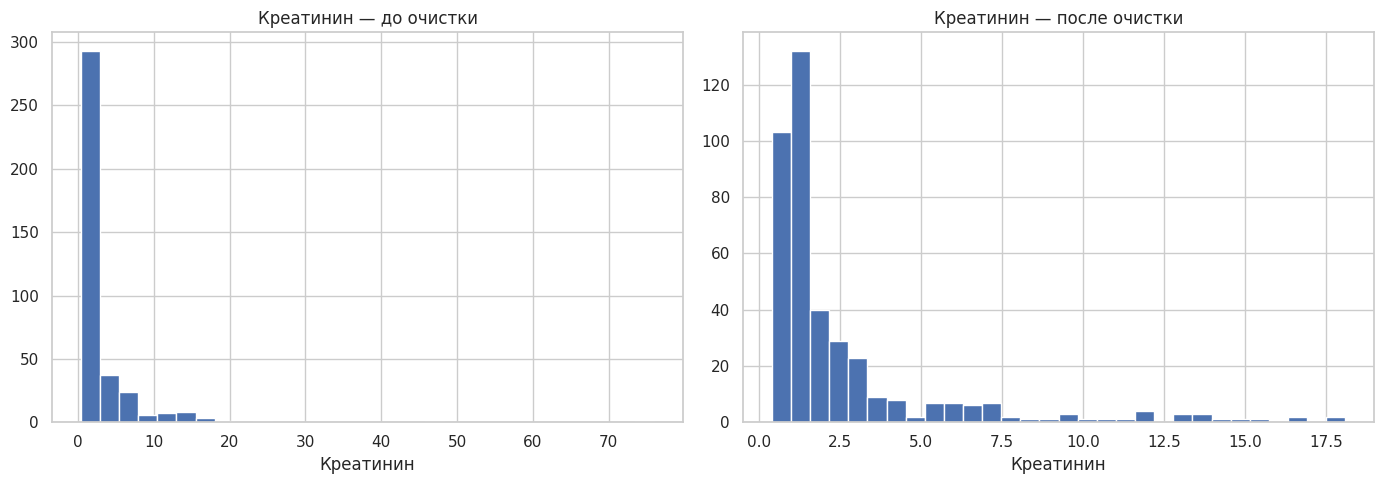

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Креатинин (sc)'].dropna(), bins=30)
axes[0].set_title('Креатинин — до очистки')
axes[0].set_xlabel('Креатинин')

axes[1].hist(df_clean['Креатинин (sc)'], bins=30)
axes[1].set_title('Креатинин — после очистки')
axes[1].set_xlabel('Креатинин')

plt.tight_layout()
plt.show()

# 7. Мини-кейс Data Cleaning

Теперь искусственно испортим исходный набор: добавим пропуски, дубликаты, сильные выбросы, некорректные значения, ошибки в категориальных признаках и неправильные типы данных. Затем будем считать, что не знаем, где именно внесены ошибки, и проведём повторный аудит.

### 7.1. Создание искусственно испорченного набора

Используем фиксированный `random_state`, чтобы результат был воспроизводимым. Целевой столбец `Диагноз (classification)` не повреждаем пропусками, потому что в ML потеря целевой переменной означает потерю обучающего наблюдения.

In [27]:
rng = np.random.default_rng(42)
df_bad = df.copy()

# 1. Около 7% пропусков в признаках.
feature_cols = numeric_cols + categorical_cols[:-1]
n_missing = int(len(df_bad) * len(feature_cols) * 0.07)
positions = rng.choice(len(df_bad) * len(feature_cols), size=n_missing, replace=False)
for pos in positions:
    r = pos // len(feature_cols)
    c = feature_cols[pos % len(feature_cols)]
    df_bad.loc[df_bad.index[r], c] = np.nan

# 2. Дубликаты.
df_bad = pd.concat([df_bad, df_bad.sample(8, random_state=42)], ignore_index=True)

# 3. Сильные выбросы.
df_bad.loc[5, 'Глюкоза_крови (bgr)'] = 5000
df_bad.loc[40, 'Креатинин (sc)'] = 150

# 4. Некорректные значения по диапазону.
df_bad.loc[20, 'Возраст (age)'] = -10
df_bad.loc[21, 'Гематокрит (pcv)'] = 150

# 5. Ошибки категорий.
df_bad.loc[30, 'Гипертония (htn)'] = ' YES '
df_bad.loc[31, 'Сахарный_диабет (dm)'] = '	NO'

# 6. Неправильный тип хранения одного числового признака.
df_bad['Возраст (age)'] = df_bad['Возраст (age)'].astype(object)
df_bad.loc[32, 'Возраст (age)'] = str(df_bad.loc[32, 'Возраст (age)'])

print(f'Испорченный набор: {df_bad.shape[0]} строк, {df_bad.shape[1]} столбцов')

Испорченный набор: 408 строк, 15 столбцов


### 7.2. Аудит испорченного набора

Снова проверим структуру, пропуски и дубликаты. Здесь важно не использовать сведения о том, какие именно ошибки мы внесли вручную: анализ должен имитировать работу с неизвестным файлом заказчика.

In [28]:
print('Структура:')
df_bad.info()

print('\nКоличество пропусков:')
print(df_bad.isna().sum().sort_values(ascending=False).head(8).to_string())

print(f'\nПолных дубликатов: {int(df_bad.duplicated().sum())}')


Структура:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Возраст (age)             376 non-null    object 
 1   Давление (bp)             377 non-null    float64
 2   Удельный_вес_мочи (sg)    330 non-null    float64
 3   Альбумин (al)             343 non-null    float64
 4   Глюкоза_крови (bgr)       344 non-null    float64
 5   Креатинин (sc)            357 non-null    float64
 6   Гемоглобин (hemo)         334 non-null    float64
 7   Гематокрит (pcv)          303 non-null    float64
 8   Лейкоциты_крови (wc)      280 non-null    float64
 9   Эритроциты_крови (rc)     256 non-null    float64
 10  Эритроциты_мочи (rbc)     227 non-null    object 
 11  Гнойные_клетки (pc)       320 non-null    object 
 12  Гипертония (htn)          380 non-null    object 
 13  Сахарный_диабет (dm)      385 non-null    object 
 14 

### 7.3. Очистка мини-кейса

Применяем те же основные правила: нормализация строк, преобразование числовых признаков, удаление полных дубликатов, исправление невозможных диапазонов, заполнение пропусков и проверка статистических выбросов.

In [29]:
def clean_dataset(data):
    out = data.copy()

    # Нормализация текстовых значений.
    for col in out.select_dtypes(include='object').columns:
        out[col] = out[col].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)
    out = out.replace('?', np.nan)

    # Восстановление правильных числовых типов.
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce')

    # Дубликаты.
    out = out.drop_duplicates().copy()

    # Невозможные значения -> NaN.
    for col, (low, high) in range_rules.items():
        bad = out[col].notna() & ((out[col] < low) | (out[col] > high))
        out.loc[bad, col] = np.nan

    # Заполнение пропусков.
    for col in numeric_cols:
        out[col] = out[col].fillna(out[col].median())
    for col in categorical_cols:
        if out[col].isna().any():
            out[col] = out[col].fillna(out[col].mode()[0])

    # Итоговые целые типы.
    for col in integer_cols:
        out[col] = out[col].round().astype('int64')

    return out


df_bad_clean = clean_dataset(df_bad)
print(f'Строки: {len(df_bad)} -> {len(df_bad_clean)}')
print(f'Пропуски: {int(df_bad.isna().sum().sum())} -> {int(df_bad_clean.isna().sum().sum())}')
print(f'Дубликаты: {int(df_bad.duplicated().sum())} -> {int(df_bad_clean.duplicated().sum())}')
print(f'Возраст после очистки: {df_bad_clean["Возраст (age)"].dtype}')

Строки: 408 -> 400
Пропуски: 1100 -> 0
Дубликаты: 8 -> 0
Возраст после очистки: int64


### 7.4. Сравнение мини-кейса до и после очистки

Сравним основные статистики числовых признаков. Это позволяет увидеть, насколько сильно искусственные ошибки повлияли на распределение и удалось ли уменьшить их влияние после очистки.

In [30]:
mini_before = df_bad[numeric_cols].apply(pd.to_numeric, errors='coerce').describe().T[['mean', 'std', '50%', 'min', 'max']]
mini_after = df_bad_clean[numeric_cols].describe().T[['mean', 'std', '50%', 'min', 'max']]
mini_compare = mini_before.join(mini_after, lsuffix=' — до', rsuffix=' — после')
display(mini_compare)

,mean — до,std — до,50% — до,min — до,max — до,mean — после,std — после,50% — после,min — после,max — после
Возраст (age),50.736,17.798,54.000,-10.000,90.000,51.125,16.816,54.000,2.000,90.000
Давление (bp),76.233,13.824,70.000,50.000,180.000,75.650,13.324,70.000,50.000,180.000
Удельный_вес_мочи (sg),1.017,0.006,1.020,1.005,1.025,1.018,0.005,1.020,1.005,1.025
Альбумин (al),1.020,1.354,0.000,0.000,5.000,0.845,1.287,0.000,0.000,5.000
Глюкоза_крови (bgr),164.305,273.675,122.000,22.000,5000.000,157.865,253.983,122.000,22.000,5000.000
Креатинин (sc),3.577,9.787,1.300,0.500,150.000,3.267,9.242,1.300,0.500,150.000
Гемоглобин (hemo),12.462,2.939,12.600,3.100,17.800,12.518,2.654,12.600,3.100,17.800
Гематокрит (pcv),38.904,11.053,40.000,9.000,150.000,39.002,7.689,40.000,9.000,54.000
Лейкоциты_крови (wc),8429.643,2981.679,8050.000,2200.000,26400.000,8334.250,2478.145,8100.000,2200.000,26400.000
Эритроциты_крови (rc),4.700,1.041,4.800,2.100,8.000,4.750,0.817,4.800,2.100,8.000


**Итоговая визуализация мини-кейса.** Покажем изменение распределения глюкозы крови — одного из признаков, в который специально был добавлен сильный искусственный выброс.

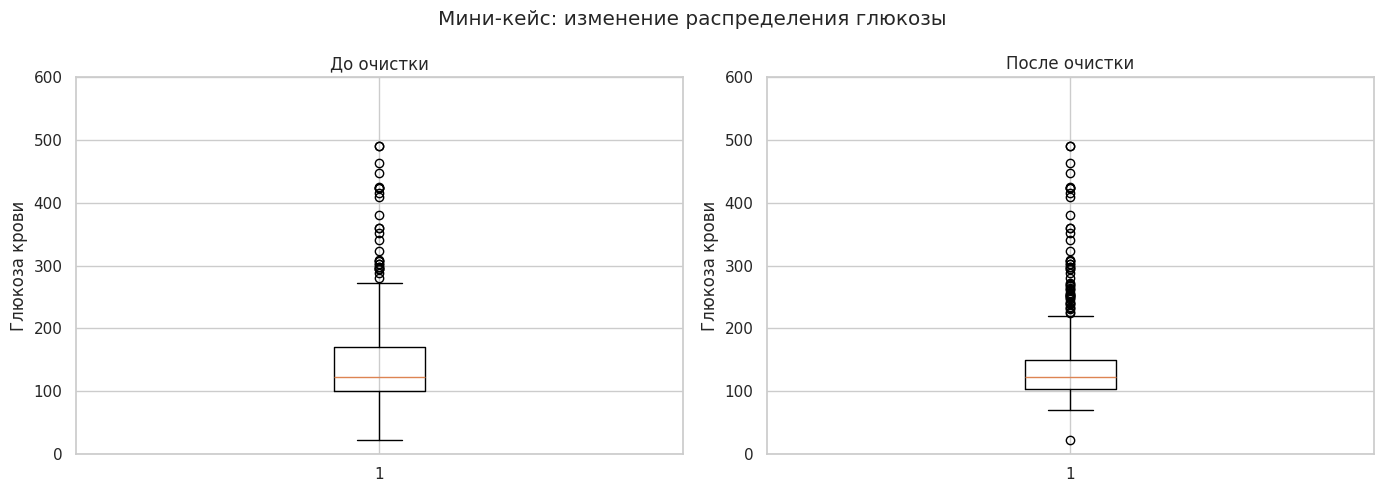

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    pd.to_numeric(
        df_bad['Глюкоза_крови (bgr)'], errors='coerce'
    ).dropna()
)
axes[0].set_title('До очистки')
axes[0].set_ylabel('Глюкоза крови')
axes[0].set_ylim(
    0, 600
)

axes[1].boxplot(df_bad_clean['Глюкоза_крови (bgr)'].dropna())
axes[1].set_title('После очистки')
axes[1].set_ylabel('Глюкоза крови')
axes[1].set_ylim(
    0, 600
)

plt.suptitle('Мини-кейс: изменение распределения глюкозы')
plt.tight_layout()
plt.show()

# 8. Итоговый вывод

В ходе лабораторной работы была исследована структура датасета, найдены пропуски, проверены дубликаты и исправлены несоответствия типов хранения. Пропуски обработаны несколькими способами, выбросы исследованы с помощью визуализации, IQR и Z-score. При очистке отдельно учитывались логически невозможные значения и статистические выбросы.

Для итогового набора данных использованы медиана для числовых признаков и мода для категориальных. После заполнения пропусков целочисленные по смыслу признаки переведены в `int64`, а дробный признак `rc` оставлен в `float64`, поскольку он содержит значения вроде 4.5.

В мини-кейсе те же методы были применены к искусственно испорченному набору без использования информации о местоположении внесённых ошибок. Это показало, что качество данных можно существенно улучшить последовательным аудитом и очисткой.